In [1]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split

In [5]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,no_dem_cand_flag,no_rep_cand_flag,dem_inc_any,rep_inc_any,dem_inc_dummy,rep_inc_dummy,pvi
0,0,2018,Alabama,AL,False,AL-01,89226.0,153228.0,242617,Robert Kennedy Jr,...,2.1,26.4,1.1,False,False,False,True,0,1,-15.715056
1,1,2018,Alabama,AL,False,AL-02,86931.0,138879.0,226230,Tabitha Isner,...,1.9,30.5,0.4,False,False,False,True,0,1,-16.880853
2,2,2018,Alabama,AL,False,AL-03,83996.0,147770.0,231915,Mallory Hagan,...,1.8,25.3,0.3,False,False,False,True,0,1,-17.206974
3,3,2018,Alabama,AL,False,AL-04,46492.0,184255.0,230969,Lee Auman,...,2.2,7.0,0.7,False,False,False,True,0,1,-31.882701
4,4,2018,Alabama,AL,False,AL-05,101388.0,159063.0,260673,Peter Joffrion,...,2.4,17.3,0.7,False,False,False,True,0,1,-18.025364


In [6]:
data = data.set_index(['year', 'district'])
data.head()

Unnamed: 0    state state_po  special       dem       rep  \
year district                                                              
2018 AL-01              0  Alabama       AL    False   89226.0  153228.0   
     AL-02              1  Alabama       AL    False   86931.0  138879.0   
     AL-03              2  Alabama       AL    False   83996.0  147770.0   
     AL-04              3  Alabama       AL    False   46492.0  184255.0   
     AL-05              4  Alabama       AL    False  101388.0  159063.0   

               totalvotes           dem_cand         rep_cand dem_inc  ...  \
year district                                                          ...   
2018 AL-01         242617  Robert Kennedy Jr    Bradley Byrne   False  ...   
     AL-02         226230      Tabitha Isner      Martha Roby   False  ...   
     AL-03         231915      Mallory Hagan      Mike Rogers   False  ...   
     AL-04         230969          Lee Auman  Robert Aderholt   False  ...   
     AL-05         260673     Peter Joffrion        Mo Brooks   False  ...   

              cvap_hisp_pct cvap_black_pct cvap_natam_pct  no_dem_cand_flag  \
year district                                                                 
2018 AL-01              2.1           26.4            1.1             False   
     AL-02              1.9           30.5            0.4             False   
     AL-03              1.8           25.3            0.3             False   
     AL-04              2.2            7.0            0.7             False   
     AL-05              2.4           17.3            0.7             False   

               no_rep_cand_flag  dem_inc_any  rep_inc_any  dem_inc_dummy  \
year district                                                              
2018 AL-01                False        False         True              0   
     AL-02                False        False         True              0   
     AL-03                False        False         True              0   
     AL-04                False        False         True              0   
     AL-05                False        False         True              0   

               rep_inc_dummy        pvi  
year district                            
2018 AL-01                 1 -15.715056  
     AL-02                 1 -16.880853  
     AL-03                 1 -17.206974  
     AL-04                 1 -31.882701  
     AL-05                 1 -18.025364  

[5 rows x 41 columns]

In [7]:
data.columns.values

array(['Unnamed: 0', 'state', 'state_po', 'special', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'prev_lean', 'prev2_lean',
       'generic_ballot_avg', 'pres_approval_avg', 'incumbent_pres', 'ics',
       'pres_approval_avg_x_incpres', 'ics_x_incpres', 'cvap_white_pct',
       'cvap_asn_pct', 'cvap_hisp_pct', 'cvap_black_pct',
       'cvap_natam_pct', 'no_dem_cand_flag', 'no_rep_cand_flag',
       'dem_inc_any', 'rep_inc_any', 'dem_inc_dummy', 'rep_inc_dummy',
       'pvi'], dtype=object)

In [8]:
data['rep_tot_funds'].isna().any()

np.False_

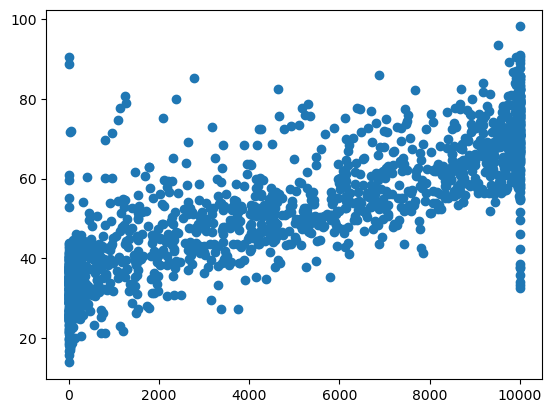

In [9]:
plt.scatter(data['dem_funds_2p_pct']**2, data['dem_pct_2p'])

In [10]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2

## Preliminary Model Check (Frequentist OLS)

In [44]:
y = data['dem_pct_2p']
X = data[['prev_lean', 'prev2_lean', 'generic_ballot_avg',
         'dem_inc_dummy', 'rep_inc_dummy', 'dem_funds_2p_pct_sqrd',
         'cvap_black_pct', 'cvap_hisp_pct', 'cvap_white_pct', 'cvap_asn_pct']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [45]:
X.corr()

,prev_lean,prev2_lean,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,cvap_black_pct,cvap_hisp_pct,cvap_white_pct,cvap_asn_pct
prev_lean,1.000000,0.977781,0.054882,0.717120,-0.685740,0.788305,0.399070,0.315282,-0.620755,0.439353
prev2_lean,0.977781,1.000000,0.053229,0.720225,-0.684134,0.783366,0.403067,0.363407,-0.655810,0.431945
generic_ballot_avg,0.054882,0.053229,1.000000,0.012585,-0.041206,-0.040506,0.032343,0.059253,-0.080474,0.058321
dem_inc_dummy,0.717120,0.720225,0.012585,1.000000,-0.723986,0.694815,0.223021,0.257602,-0.441759,0.343895
rep_inc_dummy,-0.685740,-0.684134,-0.041206,-0.723986,1.000000,-0.694265,-0.219795,-0.238061,0.416481,-0.310691
dem_funds_2p_pct_sqrd,0.788305,0.783366,-0.040506,0.694815,-0.694265,1.000000,0.222119,0.250400,-0.445990,0.367420
cvap_black_pct,0.399070,0.403067,0.032343,0.223021,-0.219795,0.222119,1.000000,-0.114895,-0.489077,-0.105299
cvap_hisp_pct,0.315282,0.363407,0.059253,0.257602,-0.238061,0.250400,-0.114895,1.000000,-0.737071,0.216051
cvap_white_pct,-0.620755,-0.655810,-0.080474,-0.441759,0.416481,-0.445990,-0.489077,-0.737071,1.000000,-0.430830
cvap_asn_pct,0.439353,0.431945,0.058321,0.343895,-0.310691,0.367420,-0.105299,0.216051,-0.430830,1.000000


In [46]:
np.linalg.matrix_rank(X)

np.int64(10)

In [47]:
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             dem_pct_2p   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     4884.
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:26:09   Log-Likelihood:                -2543.2
No. Observations:                1035   AIC:                             5108.
Df Residuals:                    1024   BIC:                             5163.
Df Model:                          10                                         
Covariance Type:                  HC1                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    55.9575      3.139     17.825      0.000      49.805      62.110
prev_lean                 0.6155      0.036     16.931      0.000       0.544       0.687
prev2_lean                0.3000      0.036      8.256      0.000       0.229       0.371
generic_ballot_avg       -0.3768      0.024    -15.550      0.000      -0.424      -0.329
dem_inc_dummy             0.7151      0.343      2.083      0.037       0.042       1.388
rep_inc_dummy            -1.4094      0.292     -4.830      0.000      -1.981      -0.837
dem_funds_2p_pct_sqrd     0.0004   4.98e-05      8.693      0.000       0.000       0.001
cvap_black_pct           -0.0824      0.032     -2.608      0.009      -0.144      -0.020
cvap_hisp_pct            -0.1138      0.033     -3.435      0.001      -0.179      -0.049
cvap_white_pct           -0.0733      0.032     -2.309      0.021      -0.136      -0.011
cvap_asn_pct             -0.1100      0.038     -2.859      0.004      -0.185      -0.035
==============================================================================
Omnibus:                      551.154   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12253.111
Skew:                           1.954   Prob(JB):                         0.00
Kurtosis:                      19.397   Cond. No.                     2.04e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 2.04e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [48]:
y_test_hat = reg.predict(sm.add_constant(X_test))
X_test['residuals'] = y_test_hat - y_test
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(8.495322335408058), np.float64(2.1174653626059583))

In [49]:
y_test - y_test_hat

year  district
2024  TX-21       0.764793
2020  MD-06      -0.621796
2024  HI-01       6.364492
2020  KY-05      -3.597665
2022  TX-16      -0.045484
                    ...   
      MA-08       3.249620
2024  IL-05      -1.749647
2020  WA-06      -2.174444
2022  PA-16       4.610838
2020  VA-02      -1.349258
Length: 510, dtype: float64

In [50]:
X_test.corr()

,prev_lean,prev2_lean,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,cvap_black_pct,cvap_hisp_pct,cvap_white_pct,cvap_asn_pct,residuals
prev_lean,1.000000,0.976544,0.048330,0.733823,-0.685415,0.794420,0.375320,0.305868,-0.599211,0.408293,0.070714
prev2_lean,0.976544,1.000000,0.048048,0.727630,-0.681384,0.782855,0.377739,0.376657,-0.648052,0.385611,0.082717
generic_ballot_avg,0.048330,0.048048,1.000000,0.021430,-0.027413,-0.049967,0.067619,0.057065,-0.079010,-0.021778,-0.083727
dem_inc_dummy,0.733823,0.727630,0.021430,1.000000,-0.745287,0.711755,0.165689,0.283849,-0.451809,0.362292,0.076091
rep_inc_dummy,-0.685415,-0.681384,-0.027413,-0.745287,1.000000,-0.709120,-0.161578,-0.245647,0.406742,-0.326560,-0.024424
dem_funds_2p_pct_sqrd,0.794420,0.782855,-0.049967,0.711755,-0.709120,1.000000,0.212655,0.250607,-0.447195,0.356929,0.040248
cvap_black_pct,0.375320,0.377739,0.067619,0.165689,-0.161578,0.212655,1.000000,-0.136986,-0.429029,-0.120387,0.081071
cvap_hisp_pct,0.305868,0.376657,0.057065,0.283849,-0.245647,0.250607,-0.136986,1.000000,-0.759481,0.177752,-0.002694
cvap_white_pct,-0.599211,-0.648052,-0.079010,-0.451809,0.406742,-0.447195,-0.429029,-0.759481,1.000000,-0.423928,-0.036394
cvap_asn_pct,0.408293,0.385611,-0.021778,0.362292,-0.326560,0.356929,-0.120387,0.177752,-0.423928,1.000000,-0.022383


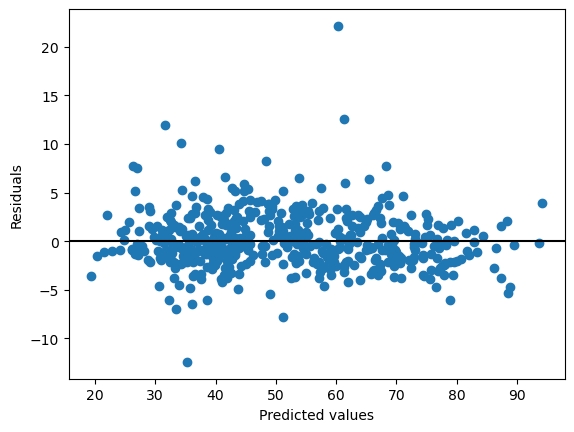

In [51]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

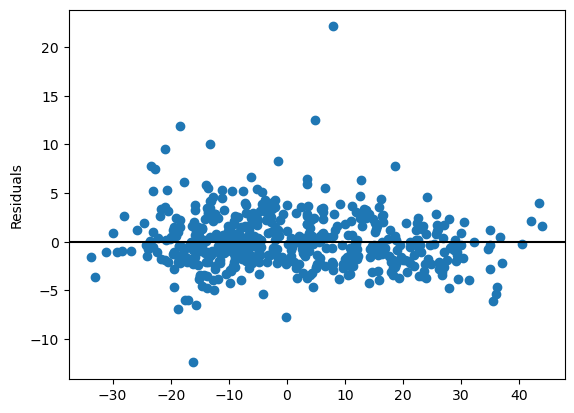

In [52]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

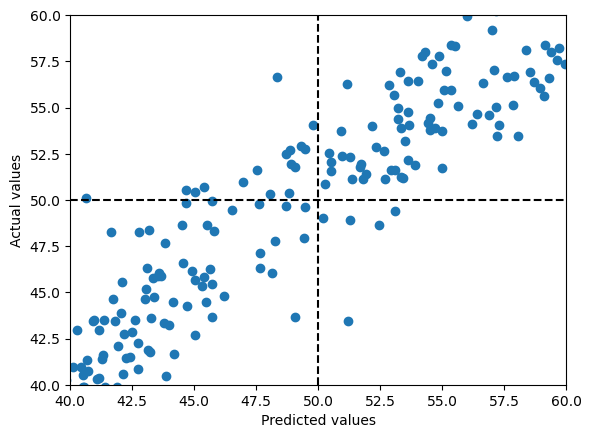

In [53]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Actual values');

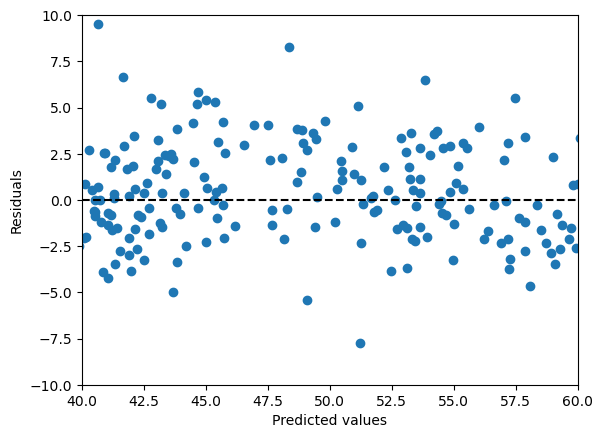

In [54]:
# Actual vs residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(-10, 10)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [55]:
resid = pd.DataFrame(y_test_hat - y_test)
resid = resid.reset_index().rename({0: 'resid'}, axis=1)
resid.head()

,year,district,resid
0,2024,TX-21,-0.764793
1,2020,MD-06,0.621796
2,2024,HI-01,-6.364492
3,2020,KY-05,3.597665
4,2022,TX-16,0.045484


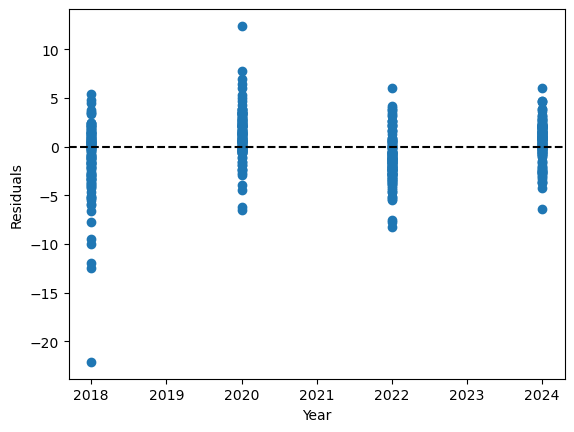

In [56]:
plt.scatter(resid['year'], resid['resid'])
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--');

In [57]:
durbin_watson(reg.resid)

np.float64(2.044516598640772)